# Random Forest
- **Uma random forest** é um algoritmo que utiliza de um conjunto de decision trees para tomar uma decisão, nesse caso classificar um registro (para problemas de classificação) ou estimar um valor (para problemas de regressão).
- Para o caso da classificação, cada decision tree prevê o resultado de uma forma e a classe final é escolhida através da moda do resultado, a classe que mais aparecer, vence. Esse método é conhecido como Bagging.
- Random Forests utilizam amostras com reposição, ou seja, uma mesma amostra pode estar presente em mais de uma decision tree.
- Através de Random Forests, o problema comum de uma única Decision Tree sofrer de Overfitting é resolvido.
<img src="https://media.geeksforgeeks.org/wp-content/uploads/20260306111717662229/random_forest_algorithm.webp" style="width: 600px;"/>

- **Utilizando o dataset iris**
    - https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris

In [2]:
# Importando o pandas
import pandas as pd

In [3]:
# Importando o dataset iris
from sklearn.datasets import load_iris

In [4]:
# Retornando os dados
data = load_iris()

In [5]:
# Transformando em um DataFrame
iris = pd.DataFrame(data.data)
iris.columns = data.feature_names
iris['target'] = data.target
iris.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


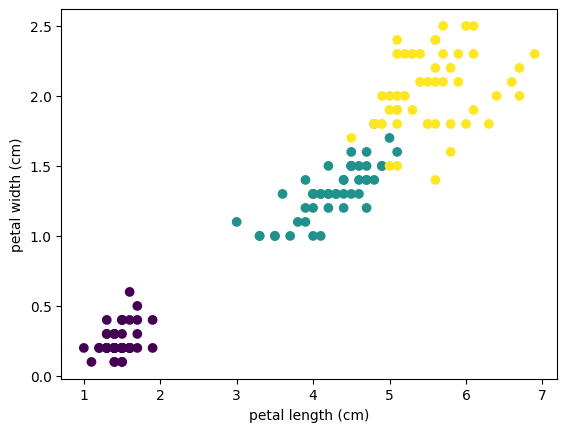

In [49]:
# Visualizando os dados
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.scatter(iris['petal length (cm)'], iris['petal width (cm)'], c=iris['target'])
ax.set_xlabel('petal length (cm)')
ax.set_ylabel('petal width (cm)')

plt.show()

In [6]:
# Separando X e y da base completa
X = iris.drop('target', axis=1)
y = iris.target

In [7]:
# Fazendo o train_test_split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [17]:
# Criando o classificador e fazendo o fit
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42, min_samples_leaf=1, max_features='sqrt', n_jobs=-1)
clf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [18]:
# Verificando o score
clf.score(X_train, y_train)

1.0

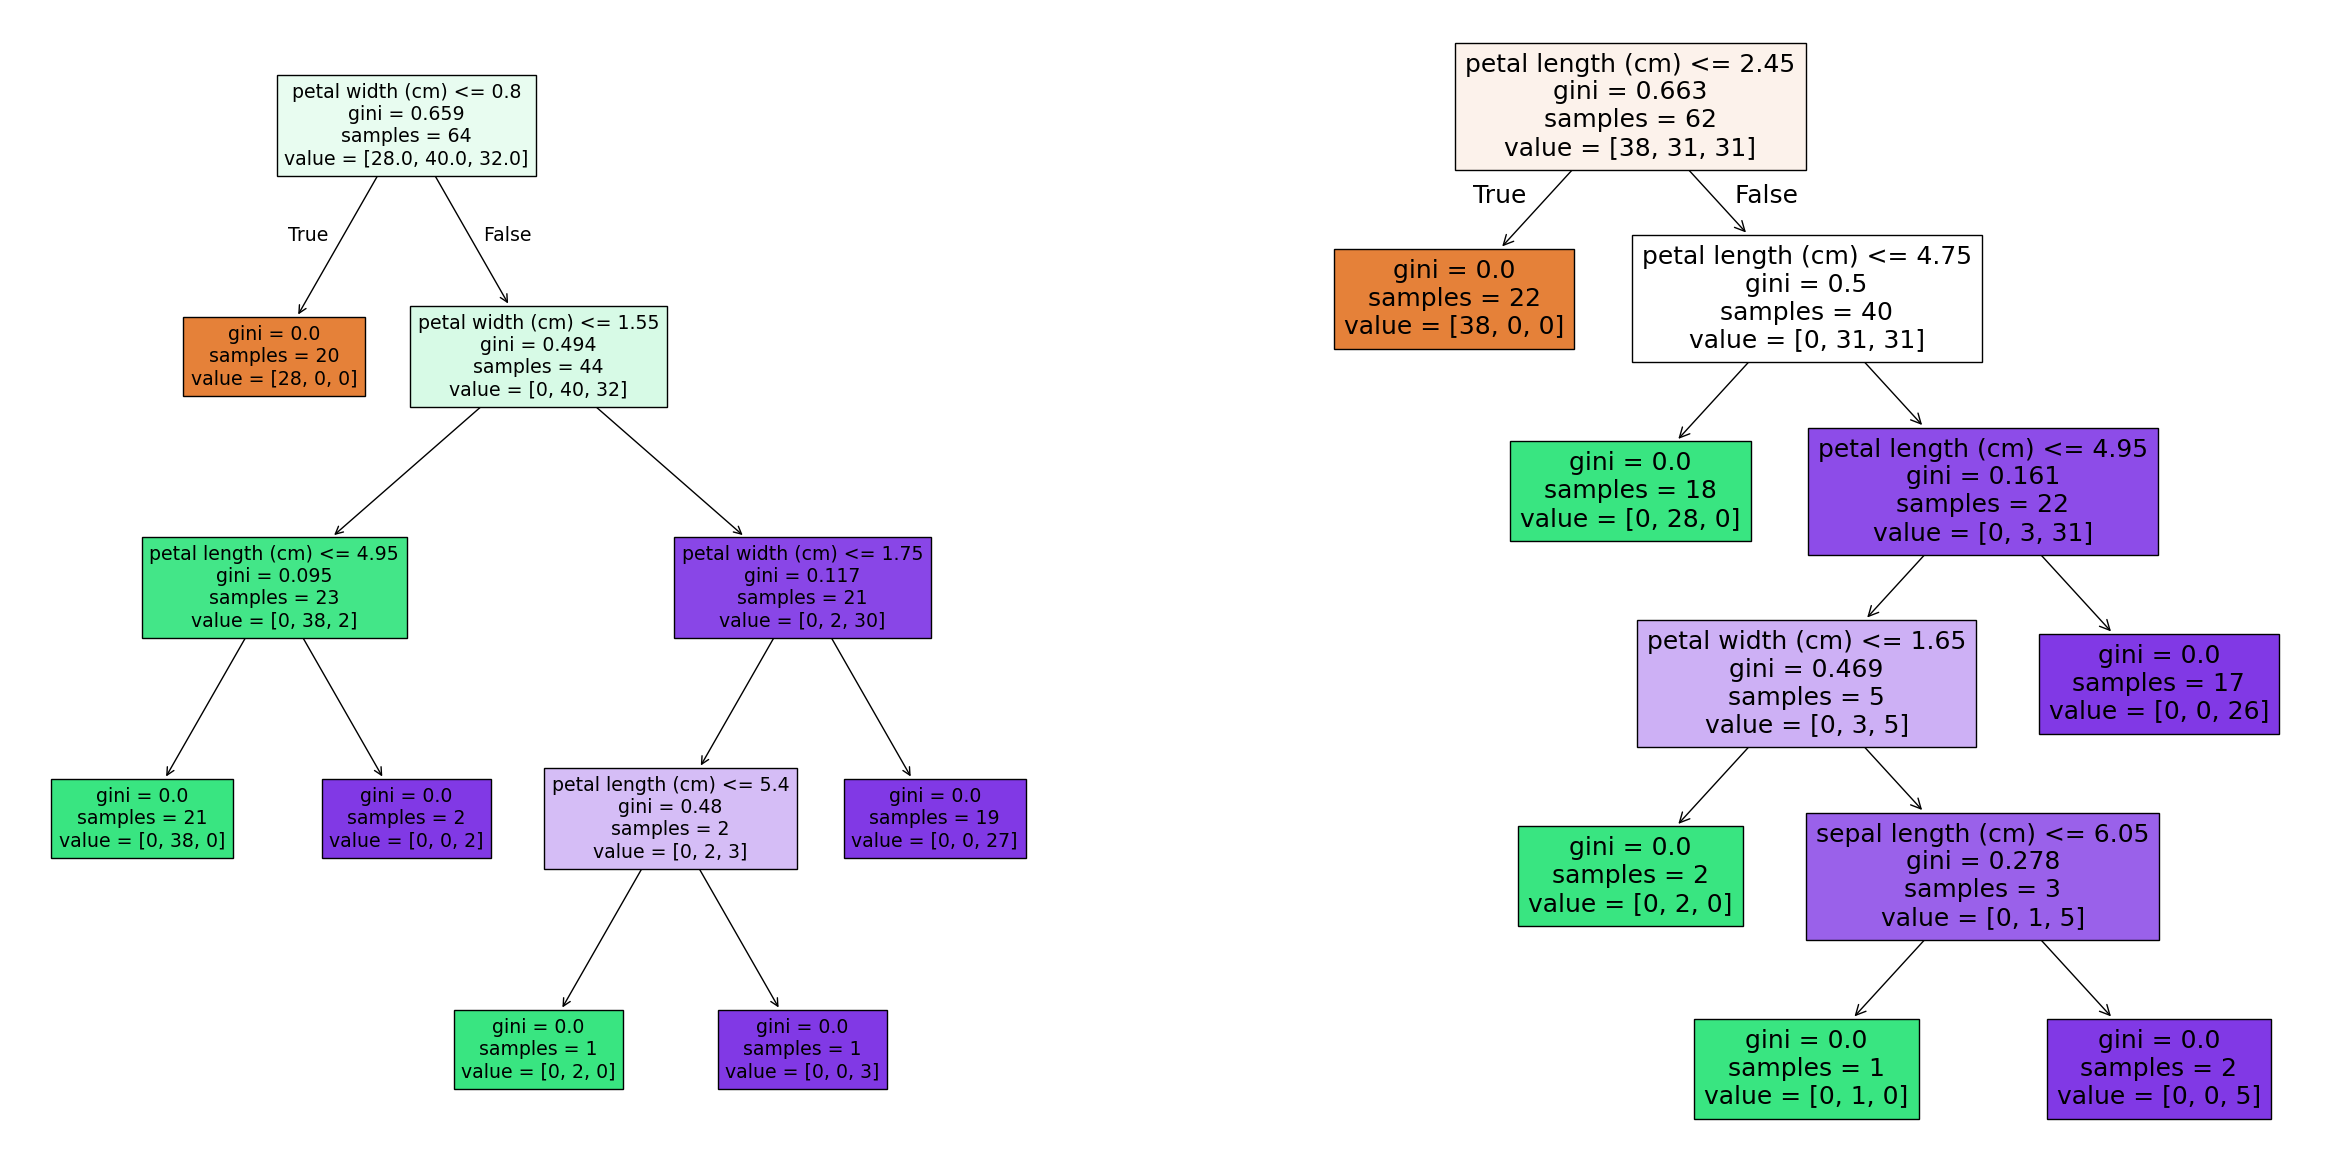

In [66]:
# Visualizando a random forest
import matplotlib.pyplot as plt
from sklearn import tree

n_forests = 2
fig, ax = plt.subplots(figsize=(30, 15), nrows=1, ncols=n_forests)

for i in range(n_forests):
    tree.plot_tree(clf.estimators_[i], feature_names=X.columns, ax=ax[i], filled=True)

plt.show()

In [42]:
# Fazendo a previsão
y_pred = clf.predict(X_test)

In [43]:
# Avaliando o modelo
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[19,  0,  0],
       [ 0, 15,  0],
       [ 0,  1, 15]])